In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_auc_score
from typing import Dict, Tuple

# ============================================================
# LOADING
# ============================================================

notebook_dir = Path.cwd()
phase2_candidates = [
    notebook_dir / "../../phase2_results",
    notebook_dir / "../phase2_results",
    notebook_dir / "phase2_results",
    Path("phase2_results"),
]

phase2_dir = next((p.resolve() for p in phase2_candidates if p.exists()), None)
if phase2_dir is None:
    searched = "\n".join(str(p.resolve()) for p in phase2_candidates)
    raise FileNotFoundError(f"phase2_results directory not found. Checked:\n{searched}")

dfs_by_file = {}
loaded_files = []

for n in range(10, 201, 10):
    pattern = f"sequences_n{n}*.parquet"
    matches = sorted(phase2_dir.glob(pattern))
    if not matches:
        print(f"  [missing] {phase2_dir / pattern}")
        continue
    for file_path in matches:
        file_df = pd.read_parquet(file_path)
        file_df["source_file"] = file_path.name
        file_df["n_target"]    = n

        key_cols = ["sample_id", "item", "prompt", "response"]
        for col in key_cols:
            if col not in file_df.columns:
                file_df[col] = ""

        file_df["sample_key"] = (
            file_df["sample_id"].fillna("").astype(str).str.strip() + "||" +
            file_df["item"].fillna("").astype(str).str.strip() + "||" +
            file_df["prompt"].fillna("").astype(str).str.strip() + "||" +
            file_df["response"].fillna("").astype(str).str.strip()
        )

        dfs_by_file[file_path.name] = file_df
        loaded_files.append(file_path)

if not dfs_by_file:
    raise FileNotFoundError("No parquet files found for sequences_n10..sequences_n200")

print(f"Loaded {len(dfs_by_file)} files\n")

# ============================================================
# SPLITTING: one greedy df + one stochastic df per file
# ============================================================
# 'error' column = absolute prediction error  |label_pred - label_true|
# It is stored at the sample level (same value repeated for all rows of a sample)
# 'semantic_entropy' and 'num_clusters' are also sample-level

greedy_dfs     = {}   # fname -> greedy rows only (one row per sample)
stochastic_dfs = {}   # fname -> stochastic rows only (n rows per sample)
metrics_dfs    = {}   # fname -> one row per sample with all eval columns

for fname, raw in dfs_by_file.items():
    n_target = raw["n_target"].iloc[0]

    # ── split ──────────────────────────────────────────────
    greedy = raw[raw["is_greedy"] == True].copy()
    stoch  = raw[raw["is_greedy"] == False].copy()

    # ── rename 'error' to be explicit ──────────────────────
    for frame in (greedy, stoch):
        if "error" in frame.columns:
            frame.rename(columns={"error": "abs_prediction_error"}, inplace=True)

    greedy_dfs[fname]     = greedy
    stochastic_dfs[fname] = stoch

    # ── sample-level metrics table ─────────────────────────
    # Pull sample-level columns from greedy rows (one row per sample)
    sample_cols = [
        "sample_key", "sample_id", "item", "prompt", "response",
        "label_true", "semantic_entropy", "num_clusters",
        "abs_prediction_error", "needs_review",
        "source_file", "n_target",
    ]
    sample_cols = [c for c in sample_cols if c in greedy.columns]
    metrics_dfs[fname] = greedy[sample_cols].reset_index(drop=True)

# ============================================================
# METRICS CALCULATOR
# ============================================================

def compute_metrics(metrics_df: pd.DataFrame) -> Dict[str, float]:
    """
    Compute calibration metrics for one file's sample-level DataFrame.
    Requires columns: semantic_entropy, abs_prediction_error.
    """
    df = metrics_df.dropna(subset=["semantic_entropy", "abs_prediction_error"]).copy()

    if len(df) < 10:
        print(f"  [warning] only {len(df)} valid samples — metrics may be unreliable")

    # Correctness = error below median (matches original logic)
    error_threshold  = df["abs_prediction_error"].median()
    df["is_correct"] = (df["abs_prediction_error"] <= error_threshold).astype(int)

    pearson_corr,  pearson_pval  = pearsonr(df["semantic_entropy"],  df["abs_prediction_error"])
    spearman_corr, spearman_pval = spearmanr(df["semantic_entropy"], df["abs_prediction_error"])

    # AUROC: does high entropy predict high error?
    auroc = roc_auc_score(1 - df["is_correct"], df["semantic_entropy"])

    return {
        "n_samples":           len(df),
        "n_flagged_review":    int(df["needs_review"].sum()) if "needs_review" in df.columns else np.nan,
        "pearson_r":           round(pearson_corr,  4),
        "pearson_p":           round(pearson_pval,  4),
        "spearman_r":          round(spearman_corr, 4),
        "spearman_p":          round(spearman_pval, 4),
        "auroc":               round(auroc,          4),
        "mean_entropy":        round(df["semantic_entropy"].mean(),        4),
        "std_entropy":         round(df["semantic_entropy"].std(),         4),
        "mean_abs_error":      round(df["abs_prediction_error"].mean(),    4),
        "median_abs_error":    round(df["abs_prediction_error"].median(),  4),
        "mean_num_clusters":   round(df["num_clusters"].mean(),            4),
    }


# ── Run metrics across all files ───────────────────────────
all_metrics = []

for fname, metrics_df in metrics_dfs.items():
    n_target = metrics_df["n_target"].iloc[0]
    print(f"Computing metrics for {fname}  (n={n_target}) ...", end=" ")
    try:
        m = compute_metrics(metrics_df)
        m["source_file"] = fname
        m["n_target"]    = n_target
        all_metrics.append(m)
        print(f"done  |  AUROC={m['auroc']}  pearson_r={m['pearson_r']}")
    except Exception as e:
        print(f"FAILED — {e}")

metrics_summary = (
    pd.DataFrame(all_metrics)
    .sort_values("n_target")
    .reset_index(drop=True)
)

# ============================================================
# INSPECTION
# ============================================================

print("\n" + "="*80)
print("METRICS SUMMARY ACROSS FILES")
print("="*80)
display(metrics_summary)

# Quick look at splits for first file
fname0 = loaded_files[0].name
print(f"\n{'='*80}")
print(f"GREEDY ROWS  —  {fname0}  ({len(greedy_dfs[fname0])} rows)")
print("="*80)
display(greedy_dfs[fname0].head(3))

print(f"\n{'='*80}")
print(f"STOCHASTIC ROWS  —  {fname0}  ({len(stochastic_dfs[fname0])} rows)")
print("="*80)
display(stochastic_dfs[fname0].head(3))

print(f"\n{'='*80}")
print(f"SAMPLE-LEVEL METRICS TABLE  —  {fname0}")
print("="*80)
display(metrics_dfs[fname0].head(3))

  [missing] C:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work\phase2_results\sequences_n70*.parquet
  [missing] C:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work\phase2_results\sequences_n80*.parquet
  [missing] C:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work\phase2_results\sequences_n90*.parquet
  [missing] C:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work\phase2_results\sequences_n100*.parquet
  [missing] C:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work\phase2_results\sequences_n110*.parquet
  [missing] C:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work\phase2_results\sequences_n120*.parquet
  [missing] C:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work\phase2_results\sequences_n130*.parquet
  [missing] C:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work\phase2_results\sequences_n140*.parquet
  [missing]

,n_samples,n_flagged_review,pearson_r,pearson_p,spearman_r,spearman_p,auroc,mean_entropy,std_entropy,mean_abs_error,median_abs_error,mean_num_clusters,source_file,n_target
0,500,13,-0.0056,0.9013,-0.0309,0.4912,0.4815,0.0475,0.1450,0.0747,0.0599,1.128,sequences_n10_20260217_155943.parquet,10
1,500,9,0.0335,0.4545,0.0472,0.2924,0.5107,0.0281,0.1009,0.0747,0.0599,1.096,sequences_n20_20260217_174823.parquet,20
2,500,2,0.0202,0.6528,-0.0064,0.8867,0.4898,0.0178,0.0762,0.0747,0.0599,1.076,sequences_n30_20260217_211442.parquet,30
3,500,5,0.0349,0.4356,0.0570,0.2028,0.5112,0.0224,0.0813,0.0747,0.0599,1.118,sequences_n40_20260218_010645.parquet,40
4,500,3,0.1263,0.0047,0.1020,0.0225,0.5400,0.0190,0.0753,0.0747,0.0599,1.094,sequences_n50_20260218_071726.parquet,50
5,500,3,0.0725,0.1053,0.0913,0.0413,0.5256,0.0202,0.0775,0.0747,0.0599,1.116,sequences_n60_20260219_024338.parquet,60
6,500,3,0.0725,0.1053,0.0913,0.0413,0.5256,0.0202,0.0775,0.0747,0.0599,1.116,sequences_n60_20260219_121605.parquet,60



GREEDY ROWS  —  sequences_n10_20260217_155943.parquet  (500 rows)


,sample_id,item,prompt,response,label_true,n_generations,sequence_idx,sequence_text,sequence_score,sequence_log_prob,cluster_id,is_greedy,semantic_entropy,num_clusters,abs_prediction_error,needs_review,source_file,n_target,sample_key
0,22-study_2-6200,friendly,testing friendliness at different schools,go to others schools to visit,0.251910,10,-1,go to others schools to visit,0.248779,NaN,NaN,True,0.000000,1,0.003130,False,sequences_n10_20260217_155943.parquet,10,22-study_2-6200||friendly||testing friendlines...
11,93377-study_3-6007,mind,testing mind-reading abilities,Go to different places and have them try and r...,0.267986,10,-1,Go to different places and have them try and r...,0.161743,NaN,NaN,True,0.000000,1,0.106243,False,sequences_n10_20260217_155943.parquet,10,93377-study_3-6007||mind||testing mind-reading...
22,dupe_average,ocean,an unexplored part of the ocean floor,what animals live down here?,0.333191,10,-1,what animals live down here?,0.323242,NaN,NaN,True,0.679314,2,0.009949,True,sequences_n10_20260217_155943.parquet,10,dupe_average||ocean||an unexplored part of the...



STOCHASTIC ROWS  —  sequences_n10_20260217_155943.parquet  (5000 rows)


,sample_id,item,prompt,response,label_true,n_generations,sequence_idx,sequence_text,sequence_score,sequence_log_prob,cluster_id,is_greedy,semantic_entropy,num_clusters,abs_prediction_error,needs_review,source_file,n_target,sample_key
1,22-study_2-6200,friendly,testing friendliness at different schools,go to others schools to visit,0.25191,10,0,and ask students how they would rate the frien...,0.316162,-0.566674,0.0,False,0.0,1,0.00313,False,sequences_n10_20260217_155943.parquet,10,22-study_2-6200||friendly||testing friendlines...
2,22-study_2-6200,friendly,testing friendliness at different schools,go to others schools to visit,0.25191,10,1,and observe how students and teachers interact...,0.364502,-0.306336,0.0,False,0.0,1,0.00313,False,sequences_n10_20260217_155943.parquet,10,22-study_2-6200||friendly||testing friendlines...
3,22-study_2-6200,friendly,testing friendliness at different schools,go to others schools to visit,0.25191,10,2,and talk to the students and teachers.\nSt,0.243530,-1.367428,0.0,False,0.0,1,0.00313,False,sequences_n10_20260217_155943.parquet,10,22-study_2-6200||friendly||testing friendlines...



SAMPLE-LEVEL METRICS TABLE  —  sequences_n10_20260217_155943.parquet


,sample_key,sample_id,item,prompt,response,label_true,semantic_entropy,num_clusters,abs_prediction_error,needs_review,source_file,n_target
0,22-study_2-6200||friendly||testing friendlines...,22-study_2-6200,friendly,testing friendliness at different schools,go to others schools to visit,0.251910,0.000000,1,0.003130,False,sequences_n10_20260217_155943.parquet,10
1,93377-study_3-6007||mind||testing mind-reading...,93377-study_3-6007,mind,testing mind-reading abilities,Go to different places and have them try and r...,0.267986,0.000000,1,0.106243,False,sequences_n10_20260217_155943.parquet,10
2,dupe_average||ocean||an unexplored part of the...,dupe_average,ocean,an unexplored part of the ocean floor,what animals live down here?,0.333191,0.679314,2,0.009949,True,sequences_n10_20260217_155943.parquet,10


In [3]:
# ============================================================
# BOOTSTRAP CI ANALYSIS — All files, all samples
# ============================================================

def bootstrap_ci(scores, n_bootstrap=10000, ci=0.95):
    """Bootstrap 95% CI around the mean sequence score for one sample."""
    if len(scores) < 2:
        return np.nan, np.nan, np.nan
    means = np.array([
        np.mean(np.random.choice(scores, size=len(scores), replace=True))
        for _ in range(n_bootstrap)
    ])
    lower = np.percentile(means, (1 - ci) / 2 * 100)
    upper = np.percentile(means, (1 + ci) / 2 * 100)
    mean  = np.mean(scores)
    return lower, mean, upper


def compute_ci_for_file(file_df):
    """
    For every sample in a file, compute bootstrap CI over sequence_score.
    Excludes the greedy sequence so CI reflects only the stochastic passes.
    Uses sample_key when available to avoid sample_id collisions.
    """
    stochastic = file_df[file_df['is_greedy'] == False].copy()

    group_col = 'sample_key' if 'sample_key' in stochastic.columns else 'sample_id'

    records = []
    for sample_group_id, grp in stochastic.groupby(group_col):
        scores = grp['sequence_score'].dropna().values
        lower, mean, upper = bootstrap_ci(scores)

        # Pull sample-level metadata from one row
        row = grp.iloc[0]
        records.append({
            'sample_key':           row.get('sample_key', sample_group_id),
            'sample_id':            row.get('sample_id', sample_group_id),
            'item':                 row.get('item',                 np.nan),
            'label_true':           row.get('label_true',           np.nan),
            'abs_prediction_error': row.get('abs_prediction_error', np.nan),
            'semantic_entropy':     row.get('semantic_entropy',     np.nan),
            'num_clusters':         row.get('num_clusters',         np.nan),
            'n_generations':        row.get('n_generations',        np.nan),
            'n_sequences':          len(scores),
            'ci_bootstrap_lower':   lower,
            'ci_bootstrap_mean':    mean,
            'ci_bootstrap_upper':   upper,
            'ci_bootstrap_width':   upper - lower,
        })
    return pd.DataFrame(records)


# Run across all loaded files
ci_by_file = {}

for fname, file_df in dfs_by_file.items():
    print(f"Computing CI for {fname} ...", end=" ")
    ci_df = compute_ci_for_file(file_df)
    ci_df['source_file'] = fname
    ci_df['n_target']    = file_df['n_target'].iloc[0]
    ci_by_file[fname]    = ci_df
    print(f"{len(ci_df)} samples done")

# Concatenate everything for cross-file comparison
ci_all = pd.concat(ci_by_file.values(), ignore_index=True)

print(f"\nTotal CI records: {len(ci_all)}")
print(ci_all.head())

Computing CI for sequences_n10_20260217_155943.parquet ... 500 samples done
Computing CI for sequences_n20_20260217_174823.parquet ... 500 samples done
Computing CI for sequences_n30_20260217_211442.parquet ... 500 samples done
Computing CI for sequences_n40_20260218_010645.parquet ... 500 samples done
Computing CI for sequences_n50_20260218_071726.parquet ... 500 samples done
Computing CI for sequences_n60_20260219_024338.parquet ... 500 samples done
Computing CI for sequences_n60_20260219_121605.parquet ... 500 samples done

Total CI records: 3500
                                          sample_key        sample_id  \
0  1-study_1-19||holes||why there are massive hol...     1-study_1-19   
1  1-study_1-32||communicate||a remote island wit...     1-study_1-32   
2  1-study_4-15533||planet||a new planet outside ...  1-study_4-15533   
3  10-study_1-348||friendly||testing friendliness...   10-study_1-348   
4  10-study_1-368||stars||why stars disappear fro...   10-study_1-368   

     

 n_target     mean   median      std
       10 0.227377 0.215483 0.120958
       20 0.169908 0.154291 0.078625
       30 0.139326 0.129462 0.058300
       40 0.123991 0.117037 0.052192
       50 0.112484 0.104378 0.046816
       60 0.101526 0.095029 0.040818


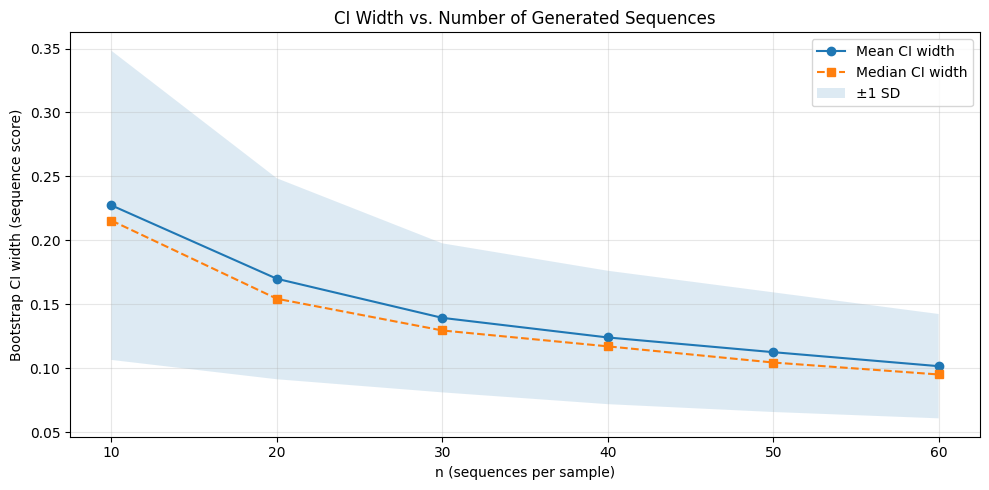

In [4]:
import matplotlib.pyplot as plt

summary = (
    ci_all
    .groupby('n_target')['ci_bootstrap_width']
    .agg(['mean', 'median', 'std'])
    .reset_index()
)

print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(summary['n_target'], summary['mean'],   marker='o', label='Mean CI width')
ax.plot(summary['n_target'], summary['median'], marker='s', label='Median CI width', linestyle='--')
ax.fill_between(
    summary['n_target'],
    summary['mean'] - summary['std'],
    summary['mean'] + summary['std'],
    alpha=0.15, label='±1 SD'
)
ax.set_xlabel('n (sequences per sample)')
ax.set_ylabel('Bootstrap CI width (sequence score)')
ax.set_title('CI Width vs. Number of Generated Sequences')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()